# 2021 code for capstone

In [7]:
import rasterio
import rasterio.plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import geopandas as gpd

In [8]:

# Set your shapefile and raster directories
shapefile_dir = r'D:\Capstone\Data\2021'
raster_dir = r'D:\Capstone\planet_image\Plot_map_2021(correct)_planet_CC0%_psscene_analytic_sr_udm2 (1)\PSScene'

# List all shapefiles in the directory
shapefiles_2021 = [os.path.join(shapefile_dir, f) for f in os.listdir(shapefile_dir) if f.endswith('.shp')]

shapefiles_2021 = [shapefiles_2021[i] for i in [1, 3] if i < len(shapefiles_2021)]

# List all raster files in the directory (e.g., .tif)
raster_files_2021 = [os.path.join(raster_dir, f) for f in os.listdir(raster_dir) if f.endswith('SR_clip.tif')]

print("Loaded shapefiles:", shapefiles_2021)
print("Loaded raster files:", raster_files_2021)

Loaded shapefiles: ['D:\\Capstone\\Data\\2021\\pixel_2021_32618.shp', 'D:\\Capstone\\Data\\2021\\tarp_polygon_2021_32618.shp']
Loaded raster files: ['D:\\Capstone\\planet_image\\Plot_map_2021(correct)_planet_CC0%_psscene_analytic_sr_udm2 (1)\\PSScene\\20210513_122812_1053_3B_AnalyticMS_SR_clip.tif', 'D:\\Capstone\\planet_image\\Plot_map_2021(correct)_planet_CC0%_psscene_analytic_sr_udm2 (1)\\PSScene\\20210514_150700_71_241e_3B_AnalyticMS_SR_clip.tif', 'D:\\Capstone\\planet_image\\Plot_map_2021(correct)_planet_CC0%_psscene_analytic_sr_udm2 (1)\\PSScene\\20210514_151831_38_225a_3B_AnalyticMS_SR_clip.tif', 'D:\\Capstone\\planet_image\\Plot_map_2021(correct)_planet_CC0%_psscene_analytic_sr_udm2 (1)\\PSScene\\20210514_151833_67_225a_3B_AnalyticMS_SR_clip.tif', 'D:\\Capstone\\planet_image\\Plot_map_2021(correct)_planet_CC0%_psscene_analytic_sr_udm2 (1)\\PSScene\\20210514_155633_47_2412_3B_AnalyticMS_SR_clip.tif', 'D:\\Capstone\\planet_image\\Plot_map_2021(correct)_planet_CC0%_psscene_analyti

In [9]:
pixel_2021_32618 = gpd.read_file(shapefiles_2021[0])
tarps_2021_32618 = gpd.read_file(shapefiles_2021[1])

In [10]:
print(pixel_2021_32618.crs)
print(tarps_2021_32618.crs)


EPSG:32618
EPSG:32618


In [11]:
pixel_2021_32618

,Join_Count,TARGET_FID,PIxel_numb,N_value,Id,PlantDate,NRate,PixelNb,Shape_Leng,Shape_Area,geometry
0,1,1,0,0,0,05/30/2021,100,3,12.0,9.0,"POLYGON Z ((380502.000 4700211.000 0.000, 3805..."
1,1,2,0,0,0,05/30/2021,0,4,12.0,9.0,"POLYGON Z ((380493.000 4700208.000 0.000, 3804..."
2,1,3,0,0,0,05/30/2021,250,9,12.0,9.0,"POLYGON Z ((380475.000 4700196.000 0.000, 3804..."
3,1,4,0,0,0,05/30/2021,0,5,12.0,9.0,"POLYGON Z ((380490.000 4700184.000 0.000, 3804..."
4,1,5,0,0,0,05/30/2021,100,2,12.0,9.0,"POLYGON Z ((380505.000 4700187.000 0.000, 3805..."
5,1,6,0,0,0,05/30/2021,100,1,12.0,9.0,"POLYGON Z ((380502.000 4700181.000 0.000, 3805..."
6,1,7,0,0,0,05/30/2021,0,6,12.0,9.0,"POLYGON Z ((380496.000 4700163.000 0.000, 3804..."
7,1,8,0,0,0,05/30/2021,250,7,12.0,9.0,"POLYGON Z ((380484.000 4700154.000 0.000, 3804..."
8,1,9,0,0,0,06/11/2021,0,12,12.0,9.0,"POLYGON Z ((380466.000 4700148.000 0.000, 3804..."
9,1,10,0,0,0,06/11/2021,250,18,12.0,9.0,"POLYGON Z ((380442.000 4700157.000 0.000, 3804..."


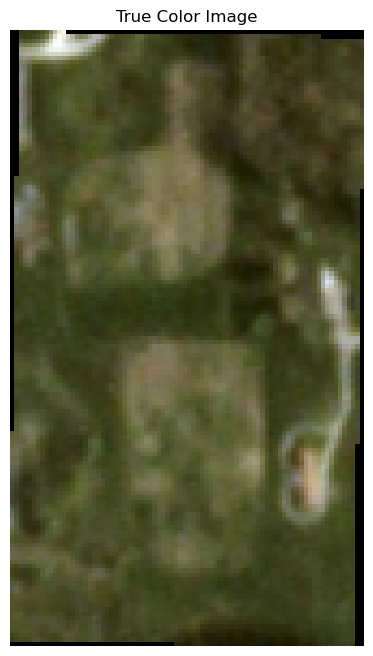

In [12]:
import rasterio
import matplotlib.pyplot as plt
import os
import numpy as np

# --- Your existing code ---
# Ensure raster_dir is defined, for example:
# raster_dir = 'path/to/your/raster_files'
# raster_files_2021 = [os.path.join(raster_dir, f) for f in os.listdir(raster_dir) if f.endswith('SR_clip.tif')]
# -------------------------

# Check if the list is not empty
if raster_files_2021:
    # Get the file path of the first image
    first_image_path = raster_files_2021[0]

    with rasterio.open(first_image_path) as src:
        # Assuming standard band order for Surface Reflectance:
        # Band 1: Blue
        # Band 2: Green
        # Band 3: Red
        # We read them into separate variables
        blue = src.read(1)
        green = src.read(2)
        red = src.read(3)

        # Function to normalize bands to 0-255 for visualization
        def normalize(array):
            # Scale values to 0-255 and convert to 8-bit unsigned integer
            array_min, array_max = np.nanmin(array), np.nanmax(array)
            return ((array - array_min) * (255 / (array_max - array_min))).astype(np.uint8)

        # Normalize each band
        red_n = normalize(red)
        green_n = normalize(green)
        blue_n = normalize(blue)

        # Stack the normalized bands to create a true color (RGB) image
        # The np.dstack function stacks arrays along the third dimension (depth-wise)
        true_color_img = np.dstack((red_n, green_n, blue_n))

        # Use matplotlib's imshow to display the RGB array
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        
        # For an RGB image, cmap is not used. Matplotlib infers it's a color image.
        ax.imshow(true_color_img)
        
        # Update the title and turn off the axes for a cleaner look
        ax.set_title("True Color Image")
        ax.set_axis_off()
        
        plt.show()
else:
    print("No raster files found in the list.")

In [13]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import os

def clip_save_and_store_rasters(raster_path, polygons_gdf, base_output_dir):
    """
    Clips a raster using polygons, saves each segment to disk,
    and returns the data in a list.
    """
    clipped_pixels_list = []
    try:
        with rasterio.open(raster_path) as src:
            # Reproject polygons if their CRS doesn't match the raster's
            polygons_to_use = polygons_gdf
            if polygons_gdf.crs != src.crs:
                print(f"  - CRS mismatch. Reprojecting polygons for {os.path.basename(raster_path)}.")
                polygons_to_use = polygons_gdf.to_crs(src.crs)

            image_name = os.path.splitext(os.path.basename(raster_path))[0]

            for index, row in polygons_to_use.iterrows():
                pixel_nb = row['PixelNb']
                output_name = f"{image_name}_pixel_{pixel_nb}"
                
                try:
                    clipped_array, clipped_transform = mask(dataset=src, shapes=[row['geometry']], crop=True)
                except ValueError:
                    # This happens if a polygon doesn't overlap the raster, skip it
                    continue

                # --- 1. SAVE TO DISK LOGIC ---
                output_folder = os.path.join(base_output_dir, f"pixel_{pixel_nb}")
                os.makedirs(output_folder, exist_ok=True)
                output_filepath = os.path.join(output_folder, f"{output_name}.tif")

                out_meta = src.meta.copy()
                out_meta.update({
                    "driver": "GTiff",
                    "height": clipped_array.shape[1],
                    "width": clipped_array.shape[2],
                    "transform": clipped_transform,
                    "crs": src.crs
                })

                with rasterio.open(output_filepath, "w", **out_meta) as dest:
                    dest.write(clipped_array)

                # --- 2. STORE IN LIST LOGIC ---
                clipped_pixels_list.append({
                    'name': output_name,
                    'pixels': clipped_array
                })
    except Exception as e:
        print(f"Could not process {raster_path}. Error: {e}")
        return []

    return clipped_pixels_list

# --- 1. DEFINE YOUR MAIN OUTPUT FOLDER ---
output_dir = r"D:\Capstone\Data\2021\pixel_2021_raster"
os.makedirs(output_dir, exist_ok=True)

# --- (Your existing code to define raster_files_2021 and pixel_2021_32618) ---
# raster_dir = 'path/to/your/raster_files'
# shapefile_path = 'path/to/your/field_polygons.shp'
# raster_files_2021 = [os.path.join(raster_dir, f) for f in os.listdir(raster_dir) if f.endswith('SR_clip.tif')]
# pixel_2021_32618 = gpd.read_file(shapefile_path)
# ----------------------------------------------------------------------------

# --- 3. Process Each Raster in the List ---
# This list will hold ALL the clipped data from ALL rasters
all_clipped_data = []

print(f"\nFound {len(raster_files_2021)} rasters to process.")
print(f"Output files will be saved in: {os.path.abspath(output_dir)}")

# Loop through each raster file path
for raster_path in raster_files_2021:
    print(f"\n--- Processing raster: {os.path.basename(raster_path)} ---")
    
    # Call the function for the current raster, passing the output directory
    results_for_one_raster = clip_save_and_store_rasters(raster_path, pixel_2021_32618, output_dir)
    
    # Add the results from this raster to our main list
    if results_for_one_raster:
        all_clipped_data.extend(results_for_one_raster)
        print(f"  > Finished. Saved and stored {len(results_for_one_raster)} segments.")

# --- 4. Display Final Results ---
if all_clipped_data:
    print("\n\n==============================")
    print("All tasks complete!")
    print(f"Total files saved to disk: {len(all_clipped_data)}")
    print(f"Total items stored in all_clipped_data list: {len(all_clipped_data)}")
    
    # Example: Accessing the first clipped result from the combined list
    first_result = all_clipped_data[0]
    print(f"\nExample - Name of first clip: {first_result['name']}")
    print(f"Example - Shape of first pixel array: {first_result['pixels'].shape}")
else:
    print("\nNo data was clipped or stored.")


Found 36 rasters to process.
Output files will be saved in: D:\Capstone\Data\2021\pixel_2021_raster

--- Processing raster: 20210513_122812_1053_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 18 segments.

--- Processing raster: 20210514_150700_71_241e_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 18 segments.

--- Processing raster: 20210514_151831_38_225a_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 18 segments.

--- Processing raster: 20210514_151833_67_225a_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 18 segments.

--- Processing raster: 20210514_155633_47_2412_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 18 segments.

--- Processing raster: 20210518_155802_27_2406_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 18 segments.

--- Processing raster: 20210518_155804_57_2406_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 18 segments.

--- Processing raster: 20210521_154131_74_105c_

In [14]:
all_clipped_data

[{'name': '20210513_122812_1053_3B_AnalyticMS_SR_clip_pixel_3',
  'pixels': array([[[ 294]],
  
         [[ 509]],
  
         [[ 710]],
  
         [[2006]]], dtype=uint16)},
 {'name': '20210513_122812_1053_3B_AnalyticMS_SR_clip_pixel_4',
  'pixels': array([[[ 286]],
  
         [[ 573]],
  
         [[ 790]],
  
         [[2021]]], dtype=uint16)},
 {'name': '20210513_122812_1053_3B_AnalyticMS_SR_clip_pixel_9',
  'pixels': array([[[ 249]],
  
         [[ 542]],
  
         [[ 752]],
  
         [[2616]]], dtype=uint16)},
 {'name': '20210513_122812_1053_3B_AnalyticMS_SR_clip_pixel_5',
  'pixels': array([[[ 345]],
  
         [[ 612]],
  
         [[ 863]],
  
         [[2264]]], dtype=uint16)},
 {'name': '20210513_122812_1053_3B_AnalyticMS_SR_clip_pixel_2',
  'pixels': array([[[ 290]],
  
         [[ 555]],
  
         [[ 765]],
  
         [[2239]]], dtype=uint16)},
 {'name': '20210513_122812_1053_3B_AnalyticMS_SR_clip_pixel_1',
  'pixels': array([[[ 283]],
  
         [[ 572]],
  
  

In [15]:
# Get metadata from the first raster file in raster_files_2021
if raster_files_2021:
    with rasterio.open(raster_files_2021[0]) as src:
        meta = src.meta  # or use src.profile
        print(meta)
else:
    print("No raster files found.")

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 82, 'height': 143, 'count': 4, 'crs': CRS.from_epsg(32618), 'transform': Affine(3.0, 0.0, 380358.0,
       0.0, -3.0, 4700313.0)}


In [17]:
all_clipped_data[0]

{'name': '20210513_122812_1053_3B_AnalyticMS_SR_clip_pixel_3',
 'pixels': array([[[ 294]],
 
        [[ 509]],
 
        [[ 710]],
 
        [[2006]]], dtype=uint16)}

In [18]:
import pandas as pd

# Define band names in order
band_names = ['blue', 'green', 'red', 'NIR']

records = []
for item in all_clipped_data:
    name = item['name']  # e.g., 'rastername_pixel_1'
    pixel_id = name.split('_')[-1]  # e.g., '1'
    arr = item['pixels']  # shape: (bands, height, width)
    # Flatten each band and create a dict for this pixel
    row = {'name': name}
    for i, band in enumerate(band_names):
        # Flatten the band array and store as a list
        row[f'pixel_{pixel_id}_{band}'] = arr[i].flatten().tolist()
    records.append(row)

df = pd.DataFrame(records)
df.head()

,name,pixel_3_blue,pixel_3_green,pixel_3_red,pixel_3_NIR,pixel_4_blue,pixel_4_green,pixel_4_red,pixel_4_NIR,pixel_9_blue,...,pixel_8_red,pixel_8_NIR,pixel_10_blue,pixel_10_green,pixel_10_red,pixel_10_NIR,pixel_14_blue,pixel_14_green,pixel_14_red,pixel_14_NIR
0,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,[294],[509],[710],[2006],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,[286],[573],[790],[2021],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[249],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
df.to_csv(r'D:\Capstone\Data\2021\pixel_2021_values\pixel_data.csv', index=False)

In [21]:
df.shape

(648, 73)

In [22]:
df

,name,pixel_3_blue,pixel_3_green,pixel_3_red,pixel_3_NIR,pixel_4_blue,pixel_4_green,pixel_4_red,pixel_4_NIR,pixel_9_blue,...,pixel_8_red,pixel_8_NIR,pixel_10_blue,pixel_10_green,pixel_10_red,pixel_10_NIR,pixel_14_blue,pixel_14_green,pixel_14_red,pixel_14_NIR
0,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,[294],[509],[710],[2006],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,[286],[573],[790],[2021],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[249],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,20211028_152116_97_2233_3B_AnalyticMS_SR_clip_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
644,20211028_152116_97_2233_3B_AnalyticMS_SR_clip_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
645,20211028_152116_97_2233_3B_AnalyticMS_SR_clip_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,[529],[1802],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
646,20211028_152116_97_2233_3B_AnalyticMS_SR_clip_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,[239],[491],[483],[2288],NaN,NaN,NaN,NaN


In [26]:
# Remove the last '_pixel_X' from the 'name' column in agg_df
agg_df = df
agg_df['name'] = df['name'].str.rsplit('_pixel', n=1).str[0]
agg_df.head()

,name,pixel_3_blue,pixel_3_green,pixel_3_red,pixel_3_NIR,pixel_4_blue,pixel_4_green,pixel_4_red,pixel_4_NIR,pixel_9_blue,...,pixel_8_red,pixel_8_NIR,pixel_10_blue,pixel_10_green,pixel_10_red,pixel_10_NIR,pixel_14_blue,pixel_14_green,pixel_14_red,pixel_14_NIR
0,20210513_122812_1053_3B_AnalyticMS_SR_clip,[294],[509],[710],[2006],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,[286],[573],[790],[2021],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[249],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# Aggregate rows by 'name', concatenating lists for each band column

def concat_lists(series):
    result = []
    for item in series:
        result.extend(item)
    return result



agg_df_name = agg_df.groupby('name')
agg_df_name.head()

,name,pixel_3_blue,pixel_3_green,pixel_3_red,pixel_3_NIR,pixel_4_blue,pixel_4_green,pixel_4_red,pixel_4_NIR,pixel_9_blue,...,pixel_8_red,pixel_8_NIR,pixel_10_blue,pixel_10_green,pixel_10_red,pixel_10_NIR,pixel_14_blue,pixel_14_green,pixel_14_red,pixel_14_NIR
0,20210513_122812_1053_3B_AnalyticMS_SR_clip,[294],[509],[710],[2006],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,[286],[573],[790],[2021],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[249],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630,20211028_152116_97_2233_3B_AnalyticMS_SR_clip,[271],[477],[537],[1911],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
631,20211028_152116_97_2233_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,[264],[496],[536],[1562],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
632,20211028_152116_97_2233_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[269],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
633,20211028_152116_97_2233_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
import pandas as pd

# Let's assume 'df' is your loaded DataFrame
# If the first column with image names is unnamed, let's fix that first.
if 'Unnamed: 0' in agg_df.columns:
    agg_df = agg_df.rename(columns={'Unnamed: 0': 'image_name'})

# Set the image name as the index for easier manipulation
agg_df = agg_df.set_index('name')

# 1. Create a MultiIndex from your column names (e.g., 'pixel_3_blue' -> ['pixel_3', 'blue'])
agg_df.columns = pd.MultiIndex.from_tuples(
    [col.rsplit('_', 1) for col in agg_df.columns],
    names=['pixel_id', 'band']
)

# 2. Stack the 'pixel_id' level. This pivots the pixel IDs from columns into rows,
#    automatically dropping all the NaN entries.
df_tidy = agg_df.stack(level='pixel_id')

# 3. Reset the index to turn 'image_name' and 'pixel_id' from index levels into columns
df_tidy = df_tidy.reset_index()

# Optional: Clean up the 'pixel_id' column to be just a number
df_tidy['pixel_id'] = df_tidy['pixel_id'].str.replace('pixel_', '').astype(int)

# Display the new, clean DataFrame
print(df_tidy.head())

band                                        name  pixel_id   blue  green  \
0     20210513_122812_1053_3B_AnalyticMS_SR_clip         3  [294]  [509]   
1     20210513_122812_1053_3B_AnalyticMS_SR_clip         4  [286]  [573]   
2     20210513_122812_1053_3B_AnalyticMS_SR_clip         9  [249]  [542]   
3     20210513_122812_1053_3B_AnalyticMS_SR_clip         5  [345]  [612]   
4     20210513_122812_1053_3B_AnalyticMS_SR_clip         2  [290]  [555]   

band    red     NIR  
0     [710]  [2006]  
1     [790]  [2021]  
2     [752]  [2616]  
3     [863]  [2264]  
4     [765]  [2239]  


In [34]:
# Assuming your DataFrame is named df_tidy
bands_to_fix = ['blue', 'green', 'red', 'NIR']

for col in bands_to_fix:
    # .str[0] accesses the first element of each list in the column
    # .astype(int) converts the result to a proper integer number
    df_tidy[col] = df_tidy[col].str[0].astype(int)

# Display the DataFrame to confirm the brackets are gone
print(df_tidy.head())

band                                        name  pixel_id  blue  green  red  \
0     20210513_122812_1053_3B_AnalyticMS_SR_clip         3   294    509  710   
1     20210513_122812_1053_3B_AnalyticMS_SR_clip         4   286    573  790   
2     20210513_122812_1053_3B_AnalyticMS_SR_clip         9   249    542  752   
3     20210513_122812_1053_3B_AnalyticMS_SR_clip         5   345    612  863   
4     20210513_122812_1053_3B_AnalyticMS_SR_clip         2   290    555  765   

band   NIR  
0     2006  
1     2021  
2     2616  
3     2264  
4     2239  


In [37]:
df_sorted.to_csv(r'D:\Capstone\Data\2021\pixel_2021_values\pixel_data_2021_sorted.csv', index=False)

In [35]:
# Assuming your DataFrame is named df_tidy
df_sorted = df_tidy.sort_values(by=['name', 'pixel_id'])

# Display the first few rows of the sorted DataFrame
print(df_sorted.head(20))

band                                           name  pixel_id  blue  green  \
5        20210513_122812_1053_3B_AnalyticMS_SR_clip         1   283    572   
4        20210513_122812_1053_3B_AnalyticMS_SR_clip         2   290    555   
0        20210513_122812_1053_3B_AnalyticMS_SR_clip         3   294    509   
1        20210513_122812_1053_3B_AnalyticMS_SR_clip         4   286    573   
3        20210513_122812_1053_3B_AnalyticMS_SR_clip         5   345    612   
6        20210513_122812_1053_3B_AnalyticMS_SR_clip         6   256    482   
7        20210513_122812_1053_3B_AnalyticMS_SR_clip         7   212    468   
15       20210513_122812_1053_3B_AnalyticMS_SR_clip         8   313    584   
2        20210513_122812_1053_3B_AnalyticMS_SR_clip         9   249    542   
16       20210513_122812_1053_3B_AnalyticMS_SR_clip        10   284    570   
11       20210513_122812_1053_3B_AnalyticMS_SR_clip        11   385    662   
8        20210513_122812_1053_3B_AnalyticMS_SR_clip        12   

In [66]:
import pandas as pd

# Assuming your DataFrame is named 'df'
# If it's not loaded, you would load it first:
# df = pd.read_csv('your_data.csv') 

# 1. Pivot the table
# - index='name': makes each unique 'name' a new row
# - columns='tarp_id': uses the values from 'tarp_id' to create new columns
# - values=['blue', 'green', 'red', 'NIR']: the values to fill the new grid
df_pixel_wide = df_sorted.pivot_table(
    index='name', 
    columns='pixel_id', 
    values=['blue', 'green', 'red', 'NIR']
)

# 2. Flatten the multi-level columns
# The pivot creates hierarchical columns like ('blue', 'tarp_r1'). 
# This step joins them into a single name like 'tarp_r1_blue'.
df_pixel_wide.columns = [f'pixel_{pixel}_{band}' for band, pixel in df_pixel_wide.columns]

# 3. Reset the index to make 'name' a regular column again
df_pixel_wide = df_pixel_wide.reset_index()

# Display the new, wide DataFrame
print(df_pixel_wide.head())

                                            name  pixel_1_NIR  pixel_2_NIR  \
0     20210513_122812_1053_3B_AnalyticMS_SR_clip       2214.0       2239.0   
1  20210514_150700_71_241e_3B_AnalyticMS_SR_clip       2544.0       2585.0   
2  20210514_151831_38_225a_3B_AnalyticMS_SR_clip       2603.0       2642.0   
3  20210514_151833_67_225a_3B_AnalyticMS_SR_clip       2601.0       2658.0   
4  20210514_155633_47_2412_3B_AnalyticMS_SR_clip       2480.0       2555.0   

   pixel_3_NIR  pixel_4_NIR  pixel_5_NIR  pixel_6_NIR  pixel_7_NIR  \
0       2006.0       2021.0       2264.0       2325.0       3379.0   
1       2508.0       2364.0       2522.0       2648.0       3492.0   
2       2631.0       2341.0       2257.0       2724.0       3453.0   
3       2521.0       2326.0       2372.0       2697.0       3389.0   
4       2632.0       2415.0       2381.0       2644.0       3392.0   

   pixel_8_NIR  pixel_9_NIR  ...  pixel_9_red  pixel_10_red  pixel_11_red  \
0       2711.0       2616.0  ... 

In [67]:
df_pixel_wide.to_csv(r'D:\Capstone\Data\2021\pixel_2021_values\pixel_data_2021_wide.csv', index=False)

# TARP values from images.

In [48]:
tarps_2021_32618_new = tarps_2021_32618.iloc[2:]

In [49]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import os

def clip_save_and_store_rasters_tarps(raster_path, polygons_gdf, base_output_dir):
    """
    Clips a raster using polygons, saves each segment to disk,
    and returns the data in a list.
    """
    clipped_pixels_list = []
    try:
        with rasterio.open(raster_path) as src:
            # Reproject polygons if their CRS doesn't match the raster's
            polygons_to_use = polygons_gdf
            if polygons_gdf.crs != src.crs:
                print(f"  - CRS mismatch. Reprojecting polygons for {os.path.basename(raster_path)}.")
                polygons_to_use = polygons_gdf.to_crs(src.crs)

            image_name = os.path.splitext(os.path.basename(raster_path))[0]

            for index, row in polygons_to_use.iterrows():
                pixel_nb = row['id']
                output_name = f"{image_name}_pixel_{pixel_nb}"
                
                try:
                    clipped_array, clipped_transform = mask(dataset=src, shapes=[row['geometry']], crop=True)
                except ValueError:
                    # This happens if a polygon doesn't overlap the raster, skip it
                    continue

                # --- 1. SAVE TO DISK LOGIC ---
                output_folder = os.path.join(base_output_dir, f"tarp_pixel_{pixel_nb}")
                os.makedirs(output_folder, exist_ok=True)
                output_filepath = os.path.join(output_folder, f"{output_name}.tif")

                out_meta = src.meta.copy()
                out_meta.update({
                    "driver": "GTiff",
                    "height": clipped_array.shape[1],
                    "width": clipped_array.shape[2],
                    "transform": clipped_transform,
                    "crs": src.crs
                })

                with rasterio.open(output_filepath, "w", **out_meta) as dest:
                    dest.write(clipped_array)

                # --- 2. STORE IN LIST LOGIC ---
                clipped_pixels_list.append({
                    'name': output_name,
                    'pixels': clipped_array
                })
    except Exception as e:
        print(f"Could not process {raster_path}. Error: {e}")
        return []

    return clipped_pixels_list

# --- 1. DEFINE YOUR MAIN OUTPUT FOLDER ---
output_dir = r"D:\Capstone\Data\2021\pixel_2021_raster"
os.makedirs(output_dir, exist_ok=True)

# --- (Your existing code to define raster_files_2021 and pixel_2021_32618) ---
# raster_dir = 'path/to/your/raster_files'
# shapefile_path = 'path/to/your/field_polygons.shp'
# raster_files_2021 = [os.path.join(raster_dir, f) for f in os.listdir(raster_dir) if f.endswith('SR_clip.tif')]
# pixel_2021_32618 = gpd.read_file(shapefile_path)
# ----------------------------------------------------------------------------

# --- 3. Process Each Raster in the List ---
# This list will hold ALL the clipped data from ALL rasters
tarp_clipped_data = []

print(f"\nFound {len(raster_files_2021)} rasters to process.")
print(f"Output files will be saved in: {os.path.abspath(output_dir)}")

# Loop through each raster file path
for raster_path in raster_files_2021:
    print(f"\n--- Processing raster: {os.path.basename(raster_path)} ---")
    
    # Call the function for the current raster, passing the output directory
    results_for_one_raster = clip_save_and_store_rasters_tarps(raster_path, tarps_2021_32618_new, output_dir)
    
    # Add the results from this raster to our main list
    if results_for_one_raster:
        tarp_clipped_data.extend(results_for_one_raster)
        print(f"  > Finished. Saved and stored {len(results_for_one_raster)} segments.")

# --- 4. Display Final Results ---
if tarp_clipped_data:
    print("\n\n==============================")
    print("All tasks complete!")
    print(f"Total files saved to disk: {len(all_clipped_data)}")
    print(f"Total items stored in all_clipped_data list: {len(all_clipped_data)}")
    
    # Example: Accessing the first clipped result from the combined list
    first_result = tarp_clipped_data[0]
    print(f"\nExample - Name of first clip: {first_result['name']}")
    print(f"Example - Shape of first pixel array: {first_result['pixels'].shape}")
else:
    print("\nNo data was clipped or stored.")


Found 36 rasters to process.
Output files will be saved in: D:\Capstone\Data\2021\pixel_2021_raster

--- Processing raster: 20210513_122812_1053_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 4 segments.

--- Processing raster: 20210514_150700_71_241e_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 4 segments.

--- Processing raster: 20210514_151831_38_225a_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 4 segments.

--- Processing raster: 20210514_151833_67_225a_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 4 segments.

--- Processing raster: 20210514_155633_47_2412_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 4 segments.

--- Processing raster: 20210518_155802_27_2406_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 4 segments.

--- Processing raster: 20210518_155804_57_2406_3B_AnalyticMS_SR_clip.tif ---
  > Finished. Saved and stored 4 segments.

--- Processing raster: 20210521_154131_74_105c_3B_Anal

In [ ]:
first_resul

{'name': '20210513_122812_1053_3B_AnalyticMS_SR_clip_pixel_r1',
 'pixels': array([[[  93]],
 
        [[ 300]],
 
        [[ 342]],
 
        [[4112]]], dtype=uint16)}

In [58]:
import pandas as pd

# Define band names in order
band_names = ['blue', 'green', 'red', 'NIR']

tarp_records = []
for item in tarp_clipped_data:
    name = item['name']  # e.g., 'rastername_pixel_1'
    tarp_id = name.split('_')[-1]  # e.g., '1'
    arr = item['pixels']  # shape: (bands, height, width)
    # Flatten each band and create a dict for this pixel
    row = {'name': name}
    for i, band in enumerate(band_names):
        # Flatten the band array and store as a list
        row[f'tarp_{tarp_id}_{band}'] = arr[i].flatten().tolist()
    tarp_records.append(row)

df_tarp = pd.DataFrame(tarp_records)
df_tarp.head()

,name,tarp_r1_blue,tarp_r1_green,tarp_r1_red,tarp_r1_NIR,tarp_w1_blue,tarp_w1_green,tarp_w1_red,tarp_w1_NIR,tarp_w2_blue,tarp_w2_green,tarp_w2_red,tarp_w2_NIR,tarp_r2_blue,tarp_r2_green,tarp_r2_red,tarp_r2_NIR
0,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,[93],[300],[342],[4112],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,[81],[281],[322],[4124],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[96],[294],[333],[4070],NaN,NaN,NaN,NaN
3,20210513_122812_1053_3B_AnalyticMS_SR_clip_pix...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[101],[294],[347],[4070]
4,20210514_150700_71_241e_3B_AnalyticMS_SR_clip_...,[322],[661],[466],[3967],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
# Remove the last '_pixel_X' from the 'name' column in agg_df

df_tarp['name'] = df_tarp['name'].str.rsplit('_pixel', n=1).str[0]
df_tarp.head()

,name,tarp_r1_blue,tarp_r1_green,tarp_r1_red,tarp_r1_NIR,tarp_w1_blue,tarp_w1_green,tarp_w1_red,tarp_w1_NIR,tarp_w2_blue,tarp_w2_green,tarp_w2_red,tarp_w2_NIR,tarp_r2_blue,tarp_r2_green,tarp_r2_red,tarp_r2_NIR
0,20210513_122812_1053_3B_AnalyticMS_SR_clip,[93],[300],[342],[4112],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,[81],[281],[322],[4124],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[96],[294],[333],[4070],NaN,NaN,NaN,NaN
3,20210513_122812_1053_3B_AnalyticMS_SR_clip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[101],[294],[347],[4070]
4,20210514_150700_71_241e_3B_AnalyticMS_SR_clip,[322],[661],[466],[3967],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
import pandas as pd

# Let's assume 'df' is your loaded DataFrame
# If the first column with image names is unnamed, let's fix that first.


# Set the image name as the index for easier manipulation
df_tarp = df_tarp.set_index('name')

# 1. Create a MultiIndex from your column names (e.g., 'pixel_3_blue' -> ['pixel_3', 'blue'])
df_tarp.columns = pd.MultiIndex.from_tuples(
    [col.rsplit('_', 1) for col in df_tarp.columns],
    names=['tarp_id', 'band']
)

# 2. Stack the 'pixel_id' level. This pivots the pixel IDs from columns into rows,
#    automatically dropping all the NaN entries.
df_tarp_tidy = df_tarp.stack(level='tarp_id')

# 3. Reset the index to turn 'image_name' and 'pixel_id' from index levels into columns
df_tarp_tidy = df_tarp_tidy.reset_index()

# Optional: Clean up the 'pixel_id' column to be just a number
# df_tidy['tarp_id'] = df_tidy['tarp_id'].str.replace('tarp_', '').astype(int)

# Display the new, clean DataFrame
print(df_tarp_tidy.head())

band                                           name  tarp_id   blue  green  \
0        20210513_122812_1053_3B_AnalyticMS_SR_clip  tarp_r1   [93]  [300]   
1        20210513_122812_1053_3B_AnalyticMS_SR_clip  tarp_w1   [81]  [281]   
2        20210513_122812_1053_3B_AnalyticMS_SR_clip  tarp_w2   [96]  [294]   
3        20210513_122812_1053_3B_AnalyticMS_SR_clip  tarp_r2  [101]  [294]   
4     20210514_150700_71_241e_3B_AnalyticMS_SR_clip  tarp_r1  [322]  [661]   

band    red     NIR  
0     [342]  [4112]  
1     [322]  [4124]  
2     [333]  [4070]  
3     [347]  [4070]  
4     [466]  [3967]  


In [61]:
# Assuming your DataFrame is named df_tidy
bands_to_fix = ['blue', 'green', 'red', 'NIR']

for col in bands_to_fix:
    # .str[0] accesses the first element of each list in the column
    # .astype(int) converts the result to a proper integer number
    df_tarp_tidy[col] = df_tarp_tidy[col].str[0].astype(int)

# Display the DataFrame to confirm the brackets are gone
print(df_tarp_tidy.head())

band                                           name  tarp_id  blue  green  \
0        20210513_122812_1053_3B_AnalyticMS_SR_clip  tarp_r1    93    300   
1        20210513_122812_1053_3B_AnalyticMS_SR_clip  tarp_w1    81    281   
2        20210513_122812_1053_3B_AnalyticMS_SR_clip  tarp_w2    96    294   
3        20210513_122812_1053_3B_AnalyticMS_SR_clip  tarp_r2   101    294   
4     20210514_150700_71_241e_3B_AnalyticMS_SR_clip  tarp_r1   322    661   

band  red   NIR  
0     342  4112  
1     322  4124  
2     333  4070  
3     347  4070  
4     466  3967  


In [62]:
df_tarp_tidy.to_csv(r'D:\Capstone\Data\2021\pixel_2021_values\tarp_data_2021.csv', index=False)

In [63]:
import pandas as pd

# Assuming your DataFrame is named 'df'
# If it's not loaded, you would load it first:
# df = pd.read_csv('your_data.csv') 

# 1. Pivot the table
# - index='name': makes each unique 'name' a new row
# - columns='tarp_id': uses the values from 'tarp_id' to create new columns
# - values=['blue', 'green', 'red', 'NIR']: the values to fill the new grid
df_tarp_wide = df_tarp_tidy.pivot_table(
    index='name', 
    columns='tarp_id', 
    values=['blue', 'green', 'red', 'NIR']
)

# 2. Flatten the multi-level columns
# The pivot creates hierarchical columns like ('blue', 'tarp_r1'). 
# This step joins them into a single name like 'tarp_r1_blue'.
df_tarp_wide.columns = [f'{tarp}_{band}' for band, tarp in df_tarp_wide.columns]

# 3. Reset the index to make 'name' a regular column again
df_tarp_wide = df_tarp_wide.reset_index()

# Display the new, wide DataFrame
print(df_tarp_wide.head())

                                            name  tarp_r1_NIR  tarp_r2_NIR  \
0     20210513_122812_1053_3B_AnalyticMS_SR_clip       4112.0       4070.0   
1  20210514_150700_71_241e_3B_AnalyticMS_SR_clip       3967.0       3977.0   
2  20210514_151831_38_225a_3B_AnalyticMS_SR_clip       4199.0       4144.0   
3  20210514_151833_67_225a_3B_AnalyticMS_SR_clip       4231.0       4198.0   
4  20210514_155633_47_2412_3B_AnalyticMS_SR_clip       3941.0       3895.0   

   tarp_w1_NIR  tarp_w2_NIR  tarp_r1_blue  tarp_r2_blue  tarp_w1_blue  \
0       4124.0       4070.0          93.0         101.0          81.0   
1       4176.0       4122.0         322.0         327.0         308.0   
2       4084.0       4115.0         237.0         239.0         219.0   
3       4116.0       4091.0         235.0         234.0         231.0   
4       3893.0       3916.0         239.0         249.0         237.0   

   tarp_w2_blue  tarp_r1_green  tarp_r2_green  tarp_w1_green  tarp_w2_green  \
0          96

In [64]:
df_tarp_wide.to_csv(r'D:\Capstone\Data\2021\pixel_2021_values\tarp_data_2021_wide.csv', index=False)